★ 너가 적은 최종안(확정본) — 내 기준으로 살짝만 다듬어서 “정본”
정본 워크플로우 (출력 1800×600 고정, crop 생략)

0. Drive 위치를 content로 옮기기
1. 원본 이미지 → bed-seg 추론 (mask/poly, conf, bbox/area 얻기)
2. 후보들에 대해 score = conf * area로 1개 선택
3. 선택된 mask/poly에서 4점(src_pts) 추출 (1차: minAreaRect)
4. src_pts를 (tl, tr, br, bl) 순서로 정렬
dst 크기 고정: (W,H)=(1800,600)
5. 원본 이미지에 warpPerspective 적용 → 이미지당 1장 “warp된 베드” 저장
원본 2600장이면 결과도 2600장
(옵션/디버그) 원본에 src_pts 오버레이 저장 (샘플 N장만)

★ 2600장 처리 “어려움” 관련 — 현실적인 운영안(짧게)
2600장 정도는 Colab GPU면 한 번에 돌릴 수도 있는데, 네가 말한 것처럼 Drive I/O 때문에 느려지거나 끊기는 경우가 많아서 보통 이렇게 함:

○ 추천 운영 방식
/content로 복사 → 처리 → 결과만 Drive로 이동
속도/안정성 제일 좋음
그리고 안전하게 가려면
chunk 300장 단위로 끊어서 저장 (중간 재시작 가능)
즉 “/content로 처리” + “chunk 저장” 둘 다 같이 쓰면 베스트.

### 0-1단계. content to bed_seg xls 출력

In [1]:
!pip -q install ultralytics opencv-python pandas tqdm openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.6 MB/s eta 0:00:00


In [2]:
# ============================================
# 0-1단계: Drive -> /content 복사 -> bed-seg 추론 -> 엑셀(테이블) 출력
# - 하위 폴더까지 재귀 탐색
# - 병렬 복사/저장
# - 진행률/남은시간(ETA) 표시
# ============================================

# [Colab 권장] 런타임 시작 후 먼저 실행
# !pip -q install ultralytics opencv-python pandas tqdm openpyxl

import os
import re
import gc
import json
import time
import math
import shutil
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch

# ultralytics (YOLOv8 seg)
from ultralytics import YOLO

# -----------------------------
# ✅ 사용자 설정
# -----------------------------
DRIVE_BASE = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/1. 원본_핵심"
OUT_FOLDER="/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP"
TARGET_FOLDERS = ["251128-251212", "251213-251226"]

# /content 쪽 작업 디렉토리
WORK_DIR = "/content/bedwarp_work"
LOCAL_IMG_DIR = os.path.join(WORK_DIR, "images")
LOCAL_OUT_DIR = os.path.join(WORK_DIR, "out")

# 결과를 Drive에 저장할 위치(원하면 바꿔도 됨)
DRIVE_OUT_DIR = os.path.join(OUT_FOLDER, "_bedseg_outputs")

# 이미지 확장자
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# bed-seg 모델 경로 (너 환경에 맞게 수정)
# - 예: /content/drive/MyDrive/models/bed_seg.pt
MODEL_PATH = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/results/runs/bed_seg_v1/weights/best.pt"  # TODO: 네 실제 경로로 바꾸기

# 추론 파라미터(안전하게)
# OOM 나면: (1) BATCH 낮추기 (2) IMGSZ 낮추기 (3) half=True 사용
CONF = 0.001 # ✅ conf 임계값 필터 안 쓰는 정책: 매우 낮게 두고 전부 받기
IOU = 0.7
IMGSZ = 832 # ✅ 더 낮춤 (누적 OOM 방지)
BATCH = 2 # ✅ seg는 1이 제일 안정적
DEVICE = 0 # GPU면 0, CPU면 'cpu'
MAX_DET = 3 # ✅ 베드면 보통 1~3개면 충분
USE_HALF = True # ✅ FP16 추론(대부분 GPU에서 메모리 절감)
CLEAN_EVERY_N = 50 # ✅ 50장마다 GPU/CPU 메모리 청소 # ✅ 이미지당 최대 검출 수 제한(베드면 보통 1~3개)
USE_HALF = True # ✅ FP16 추론(대부분 GPU에서 메모리 절감)


# 병렬 스레드 수
N_WORKERS_COPY = min(16, (os.cpu_count() or 8))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:

# -----------------------------
# 유틸
# -----------------------------

def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)


def list_images_recursive(root_dir: str, exts=IMG_EXTS):
    root = Path(root_dir)
    files = []
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in exts:
            files.append(str(p))
    return sorted(files)


def safe_relpath(path: str, start: str):
    try:
        return os.path.relpath(path, start)
    except Exception:
        return Path(path).name


def copy_one(src: str, dst: str):
    # dst 상위 폴더 생성
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    # 이미 있으면 스킵
    if os.path.exists(dst):
        return False
    shutil.copy2(src, dst)
    return True


# -----------------------------
# 0단계: Drive -> /content 로 복사
# -----------------------------

def step0_copy_drive_to_content():
    ensure_dir(LOCAL_IMG_DIR)
    ensure_dir(LOCAL_OUT_DIR)

    # 타겟 폴더별로 이미지 리스트 수집
    all_src_files = []
    for tf in TARGET_FOLDERS:
        src_root = os.path.join(DRIVE_BASE, tf)
        if not os.path.isdir(src_root):
            raise FileNotFoundError(f"Target folder not found: {src_root}")
        all_src_files.extend(list_images_recursive(src_root))

    # 로컬 목적지: target_folder/하위경로 유지
    pairs = []
    for src in all_src_files:
        # DRIVE_BASE 기준 상대경로 유지
        rel = safe_relpath(src, DRIVE_BASE)
        dst = os.path.join(LOCAL_IMG_DIR, rel)
        pairs.append((src, dst))

    # 병렬 복사 + ETA
    copied = 0
    with ThreadPoolExecutor(max_workers=N_WORKERS_COPY) as ex:
        futures = [ex.submit(copy_one, s, d) for s, d in pairs]
        for f in tqdm(as_completed(futures), total=len(futures), desc="[0] Copy Drive -> /content", unit="file"):
            try:
                if f.result():
                    copied += 1
            except Exception as e:
                print("COPY ERROR:", e)

    print(f"[0] Copy done. total={len(pairs)} copied={copied} existing_skipped={len(pairs)-copied}")

    # 로컬 이미지 루트 반환
    return LOCAL_IMG_DIR




In [5]:

# -----------------------------
# 1단계: bed-seg 추론 + 결과 테이블 생성
#  - image별 instance 단위 (mask/poly, conf, bbox, area)
# -----------------------------

def polygon_area(poly_xy: np.ndarray) -> float:
    """poly_xy: (N,2) float/ int"""
    if poly_xy is None or len(poly_xy) < 3:
        return 0.0
    x = poly_xy[:, 0]
    y = poly_xy[:, 1]
    return float(0.5 * np.abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))))


def masks_to_polygons(result):
    """ultralytics result에서 polygon list 얻기"""
    if getattr(result, "masks", None) is None:
        return []
    # result.masks.xy: list of (Ni,2) arrays
    polys = result.masks.xy
    return polys if polys is not None else []


def _chunks(lst, chunk_size:int):
    for i in range(0, len(lst), chunk_size):
        yield i//chunk_size, lst[i:i+chunk_size]


def step1_infer_bedseg_and_export(local_img_root: str, chunk_size: int = 400, resume: bool = True):
    """bed-seg 추론을 chunk 단위로 수행하고, chunk별 산출물 저장 후 최종 병합본(xlsx/csv) 생성.

    - chunk_size: 2600장 기준 300~500 추천
    - resume=True: 이미 저장된 chunk 결과가 있으면 해당 chunk는 건너뛰고 이어서 진행

    산출물:
      LOCAL_OUT_DIR/
        chunks/
          chunk_0000_summary.csv
          chunk_0000_instances_long.csv
          ...
        bedseg_summary.csv
        bedseg_instances_long.csv
        bedseg_outputs.xlsx
    """
    ensure_dir(LOCAL_OUT_DIR)
    ensure_dir(DRIVE_OUT_DIR)

    chunk_dir = os.path.join(LOCAL_OUT_DIR, "chunks")
    ensure_dir(chunk_dir)

    # 로컬 이미지 전부 수집
    img_files = list_images_recursive(local_img_root)
    if len(img_files) == 0:
        raise RuntimeError(f"No images found under: {local_img_root}")

    print(f"[1] Found {len(img_files)} images under /content")
    print(f"[1] Using chunk_size={chunk_size} (resume={resume})")

    # 모델 로드
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(
            f"MODEL_PATH not found: {MODEL_PATH}=> bed_seg.pt 경로를 MODEL_PATH에 넣어줘"
        )

    model = YOLO(MODEL_PATH)

    overall_pbar = tqdm(total=len(img_files), desc="[1] bed-seg inference (chunked)", unit="img")

    for chunk_idx, chunk_files in _chunks(img_files, chunk_size):
        chunk_tag = f"chunk_{chunk_idx:04d}"
        out_chunk_sum = os.path.join(chunk_dir, f"{chunk_tag}_summary.csv")
        out_chunk_long = os.path.join(chunk_dir, f"{chunk_tag}_instances_long.csv")

        if resume and os.path.exists(out_chunk_sum) and os.path.exists(out_chunk_long):
            # 이미 끝난 chunk는 스킵
            overall_pbar.update(len(chunk_files))
            continue

        rows = []
        summary_rows = []

        # chunk 추론
        results = model.predict(
            source=chunk_files,
            conf=CONF,
            iou=IOU,
            imgsz=IMGSZ,
            device=DEVICE,
            batch=BATCH,
            stream=True,
            verbose=False,
            half=USE_HALF,
            max_det=MAX_DET,
        )

        n_since_clean = 0
        for result in results:
            img_path = str(result.path)
            rel_from_local = safe_relpath(img_path, local_img_root)

            n_inst = 0
            best_idx = None
            best_score = -1.0

            polys = masks_to_polygons(result)

            if getattr(result, "boxes", None) is not None and result.boxes is not None and len(result.boxes) > 0:
                boxes_xyxy = result.boxes.xyxy.cpu().numpy()
                confs = result.boxes.conf.cpu().numpy()
            else:
                boxes_xyxy = np.zeros((0, 4), dtype=float)
                confs = np.zeros((0,), dtype=float)

            K = max(len(polys), len(confs))

            for i in range(K):
                poly = polys[i] if i < len(polys) else None
                conf = float(confs[i]) if i < len(confs) else float("nan")
                box = boxes_xyxy[i].tolist() if i < len(boxes_xyxy) else [float("nan")]*4

                if poly is not None and len(poly) >= 3:
                    poly_np = np.array(poly, dtype=float)
                    area = polygon_area(poly_np)
                    poly_json = json.dumps(poly_np.round(2).tolist())
                else:
                    x1, y1, x2, y2 = box
                    area = float(max(0.0, x2 - x1) * max(0.0, y2 - y1))
                    poly_json = ""

                score = (0.0 if math.isnan(conf) else conf) * area

                if score > best_score:
                    best_score = score
                    best_idx = i

                rows.append({
                    "image_rel": rel_from_local,
                    "image_abs": img_path,
                    "inst_idx": i,
                    "conf": conf,
                    "bbox_xyxy": json.dumps([round(float(v), 2) for v in box]),
                    "area_px": area,
                    "score_conf_area": score,
                    "poly_xy": poly_json,
                })
                n_inst += 1

            summary_rows.append({
                "image_rel": rel_from_local,
                "image_abs": img_path,
                "n_instances": n_inst,
                "best_idx_by_conf_area": best_idx,
                "best_score_conf_area": best_score if best_idx is not None else float("nan"),
            })

            overall_pbar.update(1)
            n_since_clean += 1

            # ✅ 50장마다 메모리 청소(누적/단편화 완화)
            if n_since_clean >= CLEAN_EVERY_N:
                # result 참조 끊기
                try:
                    del result
                except Exception:
                    pass
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                    torch.cuda.ipc_collect()
                n_since_clean = 0

        # chunk 저장 (중간저장/재시작 포인트)
        df_long = pd.DataFrame(rows)
        df_sum = pd.DataFrame(summary_rows)

        df_sum.to_csv(out_chunk_sum, index=False, encoding="utf-8-sig")
        df_long.to_csv(out_chunk_long, index=False, encoding="utf-8-sig")

        # 메모리 정리 (CPU/GPU 둘 다)
        del df_long, df_sum, rows, summary_rows
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

    overall_pbar.close()

    # -----------------------------
    # 모든 chunk 병합 -> 최종 산출물 생성
    # -----------------------------
    chunk_sum_files = sorted(Path(chunk_dir).glob("chunk_*_summary.csv"))
    chunk_long_files = sorted(Path(chunk_dir).glob("chunk_*_instances_long.csv"))

    if len(chunk_sum_files) == 0 or len(chunk_long_files) == 0:
        raise RuntimeError("No chunk outputs found. (chunks 폴더가 비어있음)")

    df_sum_all = pd.concat([pd.read_csv(f) for f in chunk_sum_files], ignore_index=True)
    df_long_all = pd.concat([pd.read_csv(f) for f in chunk_long_files], ignore_index=True)

    out_csv_long = os.path.join(LOCAL_OUT_DIR, "bedseg_instances_long.csv")
    out_csv_sum  = os.path.join(LOCAL_OUT_DIR, "bedseg_summary.csv")
    out_xlsx     = os.path.join(LOCAL_OUT_DIR, "bedseg_outputs.xlsx")

    df_long_all.to_csv(out_csv_long, index=False, encoding="utf-8-sig")
    df_sum_all.to_csv(out_csv_sum, index=False, encoding="utf-8-sig")

    with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
        df_sum_all.to_excel(writer, sheet_name="summary", index=False)
        df_long_all.to_excel(writer, sheet_name="instances_long", index=False)

    print("[1] Saved merged outputs:")
    print(" -", out_csv_sum)
    print(" -", out_csv_long)
    print(" -", out_xlsx)

    # Drive로 복사
    ensure_dir(DRIVE_OUT_DIR)
    drive_csv_long = os.path.join(DRIVE_OUT_DIR, "bedseg_instances_long.csv")
    drive_csv_sum  = os.path.join(DRIVE_OUT_DIR, "bedseg_summary.csv")
    drive_xlsx     = os.path.join(DRIVE_OUT_DIR, "bedseg_outputs.xlsx")

    shutil.copy2(out_csv_long, drive_csv_long)
    shutil.copy2(out_csv_sum, drive_csv_sum)
    shutil.copy2(out_xlsx, drive_xlsx)

    print("[1] Copied merged outputs to Drive:")
    print(" -", drive_csv_sum)
    print(" -", drive_csv_long)
    print(" -", drive_xlsx)

    # (선택) chunk 결과도 Drive로 옮기고 싶으면 아래 주석 해제
    # drive_chunk_dir = os.path.join(DRIVE_OUT_DIR, "chunks")
    # ensure_dir(drive_chunk_dir)
    # for f in Path(chunk_dir).glob("chunk_*.csv"):
    #     shutil.copy2(str(f), os.path.join(drive_chunk_dir, f.name))

    del model
    gc.collect()

    return {
        "local_img_root": local_img_root,
        "n_images": len(img_files),
        "chunk_size": chunk_size,
        "chunk_dir": chunk_dir,
        "local_outputs": [out_csv_sum, out_csv_long, out_xlsx],
        "drive_outputs": [drive_csv_sum, drive_csv_long, drive_xlsx],
    }



In [ ]:
# -----------------------------
# (선택) /content 작업폴더 정리(나중 단계에서 사용할 예정)
# -----------------------------

def cleanup_content_workdir():
    if os.path.exists(WORK_DIR):
        shutil.rmtree(WORK_DIR)
        print(f"Deleted: {WORK_DIR}")
    else:
        print(f"Not found: {WORK_DIR}")

# cleanup_content_workdir()


In [6]:
#0단계 실행
local_root = step0_copy_drive_to_content()

[0] Copy Drive -> /content:   0%|          | 0/2192 [00:00<?, ?file/s]

[0] Copy done. total=2192 copied=2192 existing_skipped=0


In [ ]:
# ✅ 1단계 실행: bed-seg 추론 + 엑셀 출력
result_info = step1_infer_bedseg_and_export(local_root)
result_info

[1] Found 2192 images under /content
[1] Using chunk_size=400 (resume=True)


[1] bed-seg inference (chunked):   0%|          | 0/2192 [00:00<?, ?img/s]

[1] Saved merged outputs:
 - /content/bedwarp_work/out/bedseg_summary.csv
 - /content/bedwarp_work/out/bedseg_instances_long.csv
 - /content/bedwarp_work/out/bedseg_outputs.xlsx
[1] Copied merged outputs to Drive:
 - /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/_bedseg_outputs/bedseg_summary.csv
 - /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/_bedseg_outputs/bedseg_instances_long.csv
 - /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/_bedseg_outputs/bedseg_outputs.xlsx


{'local_img_root': '/content/bedwarp_work/images',
 'n_images': 2192,
 'chunk_size': 400,
 'chunk_dir': '/content/bedwarp_work/out/chunks',
 'local_outputs': ['/content/bedwarp_work/out/bedseg_summary.csv',
  '/content/bedwarp_work/out/bedseg_instances_long.csv',
  '/content/bedwarp_work/out/bedseg_outputs.xlsx'],
 'drive_outputs': ['/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/_bedseg_outputs/bedseg_summary.csv',
  '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/_bedseg_outputs/bedseg_instances_long.csv',
  '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/_bedseg_outputs/bedseg_outputs.xlsx']}

###2단계: area*conf 기반으로 베드 1개 선택하기

In [8]:
# ============================================
# 2단계: 엑셀(bedseg_outputs.xlsx) 기반으로 image별 1개 선택
# - instances_long 시트 사용
# - 이미지별 인스턴스 1개면 무조건 선택
# - 2개 이상이면 score = conf * area 최대 선택
# - 병렬(옵션) + 진행률/ETA 표시
# - chunk 저장(재시작 가능)
# ============================================

import os
import gc
import time
import json
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
from tqdm.auto import tqdm


# -----------------------------
# ✅ 사용자 설정
# -----------------------------
# Drive에 저장된 bedseg_outputs.xlsx 위치
# (1단계 코드에서 DRIVE_OUT_DIR = os.path.join(DRIVE_BASE, "_bedseg_outputs") 로 복사했었음)
DRIVE_BASE = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/1. 원본_핵심"
DRIVE_XLSX= "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP"
DRIVE_OUT_DIR = os.path.join(DRIVE_XLSX, "_bedseg_outputs")
INPUT_XLSX = os.path.join(DRIVE_OUT_DIR, "bedseg_outputs.xlsx")

# /content 작업 디렉토리
WORK_DIR = "/content/bedwarp_work"
LOCAL_OUT_DIR = os.path.join(WORK_DIR, "out")

# 결과 저장(Drive)
DRIVE_SEL_DIR = os.path.join(DRIVE_XLSX, "step2_selected")

# 병렬 옵션
USE_PARALLEL = True
N_WORKERS = min(16, (os.cpu_count() or 8))

# chunk 옵션(재시작)
CHUNK_IMAGES = 400  # image 기준 chunk (300~500 추천)
RESUME = True


In [9]:


# -----------------------------
# 유틸
# -----------------------------

def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)


def safe_float(x, default=np.nan):
    try:
        return float(x)
    except Exception:
        return default


def _chunks(lst, chunk_size:int):
    for i in range(0, len(lst), chunk_size):
        yield i//chunk_size, lst[i:i+chunk_size]


# -----------------------------
# 핵심 로직: image_rel 하나에 대해 1개 row 선택
# -----------------------------

def pick_one_for_image(df_img: pd.DataFrame) -> pd.DataFrame:
    """df_img: 특정 image_rel에 대한 rows(인스턴스들)
    반환: 선택된 1개 row (DataFrame 1행)
    """
    if len(df_img) <= 1:
        return df_img.iloc[[0]]

    # score 컬럼이 없거나 비어있으면 conf*area로 계산
    if "score_conf_area" not in df_img.columns:
        score = df_img["conf"].astype(float).fillna(0) * df_img["area_px"].astype(float).fillna(0)
    else:
        # 이미 계산된 score 우선 사용
        score = pd.to_numeric(df_img["score_conf_area"], errors="coerce")
        # NaN이면 conf*area로 보완
        fallback = pd.to_numeric(df_img["conf"], errors="coerce").fillna(0) * pd.to_numeric(df_img["area_px"], errors="coerce").fillna(0)
        score = score.fillna(fallback)

    idx = score.idxmax()
    return df_img.loc[[idx]]


# -----------------------------
# 2단계 실행: 엑셀 -> image별 1개 선택 -> 저장
# -----------------------------

def step2_select_best_from_xlsx(
    input_xlsx: str = INPUT_XLSX,
    use_parallel: bool = USE_PARALLEL,
    n_workers: int = N_WORKERS,
    chunk_images: int = CHUNK_IMAGES,
    resume: bool = RESUME,
):
    ensure_dir(LOCAL_OUT_DIR)
    ensure_dir(DRIVE_SEL_DIR)

    if not os.path.exists(input_xlsx):
        raise FileNotFoundError(
            f"INPUT_XLSX not found: {input_xlsx}\n"
            "=> Drive에 bedseg_outputs.xlsx가 있는지 확인하고, INPUT_XLSX 경로를 맞춰줘"
        )

    t0 = time.time()
    print("[2] Reading Excel:", input_xlsx)

    # instances_long만 읽기
    df = pd.read_excel(input_xlsx, sheet_name="instances_long", engine="openpyxl")

    if "image_rel" not in df.columns:
        raise ValueError("instances_long 시트에 image_rel 컬럼이 없음")

    # 타입 정리
    if "conf" in df.columns:
        df["conf"] = pd.to_numeric(df["conf"], errors="coerce")
    if "area_px" in df.columns:
        df["area_px"] = pd.to_numeric(df["area_px"], errors="coerce")
    if "score_conf_area" in df.columns:
        df["score_conf_area"] = pd.to_numeric(df["score_conf_area"], errors="coerce")

    images = df["image_rel"].dropna().astype(str).unique().tolist()
    images.sort()

    print(f"[2] Total images in instances_long: {len(images)}")

    chunk_dir = os.path.join(LOCAL_OUT_DIR, "step2_chunks")
    ensure_dir(chunk_dir)

    # image_rel -> rows 빠른 접근을 위해 groupby 객체 생성(메모리 효율 괜찮음)
    g = df.groupby("image_rel", sort=False)

    # 전체 진행률
    pbar = tqdm(total=len(images), desc="[2] select best (by image)", unit="img")

    selected_parts = []

    for chunk_idx, img_chunk in _chunks(images, chunk_images):
        chunk_tag = f"chunk_{chunk_idx:04d}"
        out_chunk_csv = os.path.join(chunk_dir, f"{chunk_tag}_selected.csv")

        if resume and os.path.exists(out_chunk_csv):
            # 이미 처리한 chunk는 로드해서 병합에 포함
            part = pd.read_csv(out_chunk_csv)
            selected_parts.append(part)
            pbar.update(len(img_chunk))
            continue

        # chunk 데이터를 모아서 선택 수행
        if use_parallel and n_workers > 1:
            # 병렬 처리: image_rel 리스트를 쪼개서 작업
            def _work(img_rel: str):
                try:
                    df_img = g.get_group(img_rel)
                except KeyError:
                    return None
                picked = pick_one_for_image(df_img)
                return picked

            picked_rows = []
            with ThreadPoolExecutor(max_workers=n_workers) as ex:
                futures = {ex.submit(_work, img_rel): img_rel for img_rel in img_chunk}
                for fut in as_completed(futures):
                    res = fut.result()
                    if res is not None:
                        picked_rows.append(res)
                    pbar.update(1)

            if len(picked_rows) == 0:
                part = pd.DataFrame()
            else:
                part = pd.concat(picked_rows, ignore_index=True)
        else:
            # 단일 처리(빠름)
            picked = []
            for img_rel in img_chunk:
                try:
                    df_img = g.get_group(img_rel)
                except KeyError:
                    pbar.update(1)
                    continue
                picked.append(pick_one_for_image(df_img))
                pbar.update(1)
            part = pd.concat(picked, ignore_index=True) if picked else pd.DataFrame()

        # 선택 결과에 선택 이유 보강(선택된 score / n_instances 등)
        if not part.empty:
            # n_instances
            n_map = df.groupby("image_rel").size().rename("n_instances")
            part = part.merge(n_map, on="image_rel", how="left")

            # final_score 계산(결측 보완)
            if "score_conf_area" not in part.columns:
                part["final_score"] = part["conf"].fillna(0) * part["area_px"].fillna(0)
            else:
                part["final_score"] = part["score_conf_area"].fillna(part["conf"].fillna(0) * part["area_px"].fillna(0))

        # chunk 저장(중간 저장/재시작)
        part.to_csv(out_chunk_csv, index=False, encoding="utf-8-sig")
        selected_parts.append(part)

        # 메모리 정리
        del part
        gc.collect()

    pbar.close()

    # 병합본 생성
    selected_all = pd.concat(selected_parts, ignore_index=True) if selected_parts else pd.DataFrame()

    out_csv = os.path.join(LOCAL_OUT_DIR, "step2_selected_one_per_image.csv")
    out_xlsx = os.path.join(LOCAL_OUT_DIR, "step2_selected_one_per_image.xlsx")

    selected_all.to_csv(out_csv, index=False, encoding="utf-8-sig")
    with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
        selected_all.to_excel(writer, sheet_name="selected", index=False)

    # Drive로 복사
    drive_csv = os.path.join(DRIVE_SEL_DIR, "step2_selected_one_per_image.csv")
    drive_xlsx = os.path.join(DRIVE_SEL_DIR, "step2_selected_one_per_image.xlsx")
    ensure_dir(DRIVE_SEL_DIR)
    import shutil
    shutil.copy2(out_csv, drive_csv)
    shutil.copy2(out_xlsx, drive_xlsx)

    dt = time.time() - t0
    print(f"[2] Done. elapsed={dt/60:.1f} min")
    print("[2] Saved:")
    print(" -", out_csv)
    print(" -", out_xlsx)
    print("[2] Copied to Drive:")
    print(" -", drive_csv)
    print(" -", drive_xlsx)

    return {
        "n_images": int(len(images)),
        "input_xlsx": input_xlsx,
        "local_outputs": [out_csv, out_xlsx],
        "drive_outputs": [drive_csv, drive_xlsx],
        "chunk_dir": chunk_dir,
    }


In [10]:
# -----------------------------
# 실행 셀
# -----------------------------

# ✅ Drive에서 엑셀 읽어서 2단계 선택 실행
result2 = step2_select_best_from_xlsx(INPUT_XLSX, use_parallel=True, chunk_images=400, resume=True)
result2


[2] Reading Excel: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/_bedseg_outputs/bedseg_outputs.xlsx
[2] Total images in instances_long: 2192


[2] select best (by image):   0%|          | 0/2192 [00:00<?, ?img/s]

[2] Done. elapsed=0.2 min
[2] Saved:
 - /content/bedwarp_work/out/step2_selected_one_per_image.csv
 - /content/bedwarp_work/out/step2_selected_one_per_image.xlsx
[2] Copied to Drive:
 - /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step2_selected/step2_selected_one_per_image.csv
 - /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step2_selected/step2_selected_one_per_image.xlsx


{'n_images': 2192,
 'input_xlsx': '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/_bedseg_outputs/bedseg_outputs.xlsx',
 'local_outputs': ['/content/bedwarp_work/out/step2_selected_one_per_image.csv',
  '/content/bedwarp_work/out/step2_selected_one_per_image.xlsx'],
 'drive_outputs': ['/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step2_selected/step2_selected_one_per_image.csv',
  '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step2_selected/step2_selected_one_per_image.xlsx'],
 'chunk_dir': '/content/bedwarp_work/out/step2_chunks'}

###3단계: 선택된 mask-poly에서 4점 추출(src-pts)

In [12]:
# ============================================
# 3단계: step2_selected_one_per_image.xlsx (poly_xy 기반)
#      -> src_pts 4점 추출(minAreaRect)
#      -> tl,tr,br,bl 순서 정렬
#      -> 엑셀/CSV 저장 + 재시작 가능(chunk)
#      -> 샘플 20장 오버레이 시각검증(선택)
# ============================================

import os
import gc
import time
import json
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import cv2
from tqdm.auto import tqdm


# -----------------------------
# ✅ 사용자 설정
# -----------------------------
# 2단계 결과(Drive)
DRIVE_BASE = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/1. 원본_핵심"
DRIVE_XLSX= "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP"
DRIVE_BEDSEG_DIR = os.path.join(DRIVE_XLSX, "_bedseg_outputs")
INPUT_STEP2_XLSX = os.path.join(DRIVE_XLSX, "step2_selected", "step2_selected_one_per_image.xlsx")

# /content 작업 디렉토리 (0단계에서 이미지가 여기에 복사되어 있어야 함)
WORK_DIR = "/content/bedwarp_work"
LOCAL_IMG_DIR = os.path.join(WORK_DIR, "images")
LOCAL_OUT_DIR = os.path.join(WORK_DIR, "out")

# 3단계 결과 저장(Drive)
DRIVE_STEP3_DIR = os.path.join(DRIVE_XLSX, "step3_srcpts")

# chunk/병렬
CHUNK_IMAGES = 400
RESUME = True
USE_PARALLEL = True
N_WORKERS = min(16, (os.cpu_count() or 8))

# 샘플 오버레이 출력
SAVE_DEBUG_OVERLAY = True
DEBUG_N = 20
DEBUG_MAX_SIDE = 900  # 오버레이 저장 시 큰 변 기준 리사이즈(보기 용)

In [13]:
# -----------------------------
# 유틸
# -----------------------------

def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)


def _chunks(lst, chunk_size:int):
    for i in range(0, len(lst), chunk_size):
        yield i//chunk_size, lst[i:i+chunk_size]


def parse_poly_xy(poly_str: str) -> np.ndarray:
    """poly_xy json string -> (N,2) float32"""
    if poly_str is None:
        return None
    if isinstance(poly_str, float) and np.isnan(poly_str):
        return None
    if isinstance(poly_str, (list, tuple, np.ndarray)):
        arr = np.array(poly_str, dtype=np.float32)
        return arr
    s = str(poly_str).strip()
    if s == "":
        return None
    try:
        pts = json.loads(s)
        arr = np.array(pts, dtype=np.float32)
        if arr.ndim != 2 or arr.shape[1] != 2 or arr.shape[0] < 3:
            return None
        return arr
    except Exception:
        return None


def order_points_tl_tr_br_bl(pts4: np.ndarray) -> np.ndarray:
    """pts4: (4,2). return ordered (4,2) tl,tr,br,bl"""
    pts = np.array(pts4, dtype=np.float32)
    s = pts.sum(axis=1)        # x+y
    diff = np.diff(pts, axis=1)  # x-y

    tl = pts[np.argmin(s)]
    br = pts[np.argmax(s)]
    tr = pts[np.argmin(diff)]
    bl = pts[np.argmax(diff)]

    return np.vstack([tl, tr, br, bl]).astype(np.float32)


def min_area_rect_srcpts(poly: np.ndarray) -> np.ndarray:
    """poly: (N,2) -> minAreaRect 4pts (unordered)"""
    cnt = poly.reshape(-1, 1, 2).astype(np.float32)
    rect = cv2.minAreaRect(cnt)          # ((cx,cy),(w,h),angle)
    box = cv2.boxPoints(rect)            # (4,2) float
    return box.astype(np.float32), rect


def resize_max_side(img, max_side=900):
    h, w = img.shape[:2]
    m = max(h, w)
    if m <= max_side:
        return img, 1.0
    scale = max_side / m
    nh, nw = int(round(h * scale)), int(round(w * scale))
    out = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA)
    return out, scale


# -----------------------------
# 핵심: 한 행(이미지 1개)에서 src_pts 추출
# -----------------------------

def compute_srcpts_row(row: dict) -> dict:
    """row: step2_selected의 한 행(dict)
    return: src_pts 관련 컬럼 추가한 dict
    """
    image_rel = row["image_rel"]
    poly = parse_poly_xy(row.get("poly_xy", None))
    if poly is None:
        # poly가 항상 채워져 있다고 했지만, 안전하게 처리
        row.update({
            "src_pts": "",
            "src_tl": "",
            "src_tr": "",
            "src_br": "",
            "src_bl": "",
            "rect_center": "",
            "rect_size": "",
            "rect_angle": np.nan,
            "src_method": "poly_missing",
        })
        return row

    box4, rect = min_area_rect_srcpts(poly)
    ordered = order_points_tl_tr_br_bl(box4)

    (cx, cy), (rw, rh), angle = rect

    row.update({
        "src_pts": json.dumps(ordered.round(2).tolist()),
        "src_tl": json.dumps(ordered[0].round(2).tolist()),
        "src_tr": json.dumps(ordered[1].round(2).tolist()),
        "src_br": json.dumps(ordered[2].round(2).tolist()),
        "src_bl": json.dumps(ordered[3].round(2).tolist()),
        "rect_center": json.dumps([round(float(cx),2), round(float(cy),2)]),
        "rect_size": json.dumps([round(float(rw),2), round(float(rh),2)]),
        "rect_angle": float(angle),
        "src_method": "minAreaRect(poly)",
    })
    return row


# -----------------------------
# 3단계 실행
# -----------------------------

def step3_compute_srcpts(
    input_step2_xlsx: str = INPUT_STEP2_XLSX,
    chunk_images: int = CHUNK_IMAGES,
    resume: bool = RESUME,
    use_parallel: bool = USE_PARALLEL,
    n_workers: int = N_WORKERS,
    save_debug_overlay: bool = SAVE_DEBUG_OVERLAY,
    debug_n: int = DEBUG_N,
):
    ensure_dir(LOCAL_OUT_DIR)
    ensure_dir(DRIVE_STEP3_DIR)

    if not os.path.exists(input_step2_xlsx):
        raise FileNotFoundError(f"step2 xlsx not found: {input_step2_xlsx}")

    df = pd.read_excel(input_step2_xlsx, sheet_name="selected", engine="openpyxl")
    if "image_rel" not in df.columns:
        raise ValueError("selected 시트에 image_rel 컬럼이 없음")

    images = df["image_rel"].dropna().astype(str).tolist()
    print(f"[3] Loaded step2 selected rows: {len(images)}")

    # chunk 출력 폴더
    chunk_dir = os.path.join(LOCAL_OUT_DIR, "step3_chunks")
    ensure_dir(chunk_dir)

    # 디버그 오버레이 폴더
    debug_dir = os.path.join(LOCAL_OUT_DIR, "step3_debug_overlay")
    if save_debug_overlay:
        ensure_dir(debug_dir)

    pbar = tqdm(total=len(df), desc="[3] compute src_pts", unit="img")

    out_parts = []

    # 디버그 샘플은 전체에서 앞부분 기준으로 뽑음(원하면 랜덤으로 바꿔도 됨)
    debug_targets = set(images[:debug_n])

    for chunk_idx, idxs in _chunks(list(range(len(df))), chunk_images):
        chunk_tag = f"chunk_{chunk_idx:04d}"
        out_chunk_csv = os.path.join(chunk_dir, f"{chunk_tag}_srcpts.csv")

        if resume and os.path.exists(out_chunk_csv):
            part = pd.read_csv(out_chunk_csv)
            out_parts.append(part)
            pbar.update(len(idxs))
            continue

        sub = df.iloc[idxs].copy()
        records = sub.to_dict(orient="records")

        if use_parallel and n_workers > 1:
            out_rows = []
            with ThreadPoolExecutor(max_workers=n_workers) as ex:
                futures = [ex.submit(compute_srcpts_row, r) for r in records]
                for fut in as_completed(futures):
                    out_rows.append(fut.result())
                    pbar.update(1)
            part = pd.DataFrame(out_rows)
        else:
            out_rows = []
            for r in records:
                out_rows.append(compute_srcpts_row(r))
                pbar.update(1)
            part = pd.DataFrame(out_rows)

        # chunk 저장
        part.to_csv(out_chunk_csv, index=False, encoding="utf-8-sig")
        out_parts.append(part)

        # 선택: 디버그 오버레이 저장 (chunk 안에서 필요한 것만)
        if save_debug_overlay:
            for _, r in part.iterrows():
                img_rel = str(r["image_rel"])
                if img_rel not in debug_targets:
                    continue

                src_pts = parse_poly_xy(r.get("src_pts", ""))
                poly = parse_poly_xy(r.get("poly_xy", ""))

                img_path = os.path.join(LOCAL_IMG_DIR, img_rel)
                if not os.path.exists(img_path):
                    continue

                img = cv2.imread(img_path)
                if img is None:
                    continue

                img_small, scale = resize_max_side(img, DEBUG_MAX_SIDE)

                # 오버레이: poly(초록), src_pts(빨강 점)
                if poly is not None:
                    poly_s = (poly * scale).astype(np.int32)
                    cv2.polylines(img_small, [poly_s], isClosed=True, color=(0,255,0), thickness=2)

                if src_pts is not None and src_pts.shape == (4,2):
                    pts_s = (src_pts * scale).astype(np.int32)
                    for i, (x,y) in enumerate(pts_s):
                        cv2.circle(img_small, (int(x), int(y)), 6, (0,0,255), -1)
                        cv2.putText(img_small, str(i), (int(x)+6, int(y)-6), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)

                out_name = img_rel.replace("/", "__")
                out_path = os.path.join(debug_dir, f"{out_name}")
                ensure_dir(os.path.dirname(out_path))
                cv2.imwrite(out_path, img_small)

        # 메모리 정리
        del part, sub, records
        gc.collect()

    pbar.close()

    # 병합본
    all_df = pd.concat(out_parts, ignore_index=True) if out_parts else pd.DataFrame()

    out_csv = os.path.join(LOCAL_OUT_DIR, "step3_srcpts_one_per_image.csv")
    out_xlsx = os.path.join(LOCAL_OUT_DIR, "step3_srcpts_one_per_image.xlsx")

    all_df.to_csv(out_csv, index=False, encoding="utf-8-sig")
    with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
        all_df.to_excel(writer, sheet_name="srcpts", index=False)

    # Drive로 복사
    import shutil
    drive_csv = os.path.join(DRIVE_STEP3_DIR, "step3_srcpts_one_per_image.csv")
    drive_xlsx = os.path.join(DRIVE_STEP3_DIR, "step3_srcpts_one_per_image.xlsx")
    shutil.copy2(out_csv, drive_csv)
    shutil.copy2(out_xlsx, drive_xlsx)

    # 디버그 오버레이도 Drive로 복사(원하면)
    if save_debug_overlay:
        drive_dbg = os.path.join(DRIVE_STEP3_DIR, "debug_overlay")
        ensure_dir(drive_dbg)
        # 파일 수가 적으니 단순 복사
        for p in Path(debug_dir).glob("*"):
            shutil.copy2(str(p), os.path.join(drive_dbg, p.name))

    print("[3] Saved:")
    print(" -", out_csv)
    print(" -", out_xlsx)
    if save_debug_overlay:
        print("[3] Debug overlays:")
        print(" -", debug_dir)

    print("[3] Copied to Drive:")
    print(" -", drive_csv)
    print(" -", drive_xlsx)
    if save_debug_overlay:
        print(" -", os.path.join(DRIVE_STEP3_DIR, "debug_overlay"))

    return {
        "n_images": int(len(df)),
        "input_step2_xlsx": input_step2_xlsx,
        "local_outputs": [out_csv, out_xlsx],
        "drive_outputs": [drive_csv, drive_xlsx],
        "chunk_dir": chunk_dir,
        "debug_dir": debug_dir if save_debug_overlay else None,
    }



In [14]:
# -----------------------------
# 실행 셀
# -----------------------------

# ✅ 0단계를 이미 해둔 상태(/content/bedwarp_work/images 존재)에서 실행
result3 = step3_compute_srcpts(INPUT_STEP2_XLSX, chunk_images=400, resume=True, use_parallel=True)
result3

[3] Loaded step2 selected rows: 2192


[3] compute src_pts:   0%|          | 0/2192 [00:00<?, ?img/s]

[3] Saved:
 - /content/bedwarp_work/out/step3_srcpts_one_per_image.csv
 - /content/bedwarp_work/out/step3_srcpts_one_per_image.xlsx
[3] Debug overlays:
 - /content/bedwarp_work/out/step3_debug_overlay
[3] Copied to Drive:
 - /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step3_srcpts/step3_srcpts_one_per_image.csv
 - /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step3_srcpts/step3_srcpts_one_per_image.xlsx
 - /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step3_srcpts/debug_overlay


{'n_images': 2192,
 'input_step2_xlsx': '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step2_selected/step2_selected_one_per_image.xlsx',
 'local_outputs': ['/content/bedwarp_work/out/step3_srcpts_one_per_image.csv',
  '/content/bedwarp_work/out/step3_srcpts_one_per_image.xlsx'],
 'drive_outputs': ['/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step3_srcpts/step3_srcpts_one_per_image.csv',
  '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step3_srcpts/step3_srcpts_one_per_image.xlsx'],
 'chunk_dir': '/content/bedwarp_work/out/step3_chunks',
 'debug_dir': '/content/bedwarp_work/out/step3_debug_overlay'}

### 3단계를 보정해서 다시하기

In [19]:
# ============================================
# 3b단계 (개선/하이브리드): src_pts 보정
#
# 문제
# - minAreaRect 기반 src_pts에서 tl/bl(좌측) 점이 벽면 끝까지 튀는 케이스 다수
# - 단순 nearest-vertex 스냅은 코너가 아니라 변 중간점으로 붙어서 코너 정보 상실
#
# 해결(하이브리드)
# 1) 기본은 minAreaRect src_pts 그대로 사용
# 2) "튀는 케이스"에서만 poly 기반 코너 4점으로 교체 (추천1)
#    - poly 코너 정의:
#      tl = argmin(x+y)
#      br = argmax(x+y)
#      tr = argmin(x-y)
#      bl = argmax(x-y)
# 3) 안전장치:
#    - poly-corner로 교체했는데 tl/bl이 poly 내부/가장자리에서 너무 아래로 내려가면(상단/하단 조건 위반)
#      -> 교체 취소하고 원본 유지
#
# 출력
# - step3b_srcpts_fixed_one_per_image.xlsx/csv (src_use 컬럼에 최종 4점)
# - 디버그 오버레이 20장: poly(초록), 원본 src_pts(빨강 R0~R3), 최종 src_use(파랑 U0~U3)
# ============================================

import os
import gc
import json
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import cv2
from tqdm.auto import tqdm


# -----------------------------
# ✅ 경로 설정
# -----------------------------
DRIVE_BASE = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/1. 원본_핵심"
DRIVE_XLSX= "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP"
DRIVE_BEDSEG_DIR = os.path.join(DRIVE_XLSX, "_bedseg_outputs")
DRIVE_STEP3_DIR = os.path.join(DRIVE_XLSX, "step3_srcpts")



# step3 결과(Drive)
INPUT_STEP3_XLSX = os.path.join(DRIVE_STEP3_DIR, "step3_srcpts_one_per_image.xlsx")

WORK_DIR = "/content/bedwarp_work"
LOCAL_IMG_DIR = os.path.join(WORK_DIR, "images")
LOCAL_OUT_DIR = os.path.join(WORK_DIR, "out")

DRIVE_STEP3B_DIR = os.path.join(DRIVE_STEP3_DIR, "step3b_srcpts_fixed")


# -----------------------------
# ✅ 하이브리드 파라미터
# -----------------------------
# "튀는 케이스" 판단 기준(둘 중 하나면 교체 고려)
SNAP_X_FRAC = 0.06     # tl 또는 bl의 x가 이미지 폭의 6% 이내면(너무 왼쪽)
SNAP_LEFT_MARGIN = 40  # tl/bl이 poly의 xmin보다 40px 이상 왼쪽으로 튀면

# poly-corner 교체 후 안전장치(코너가 중간점으로 내려앉는 것 방지)
# - tl은 poly의 상단 근처여야 함 (y <= ymin + frac*(ymax-ymin))
# - bl은 poly의 하단 근처여야 함 (y >= ymax - frac*(ymax-ymin))
TOP_FRAC = 0.25
BOT_FRAC = 0.25

# chunk/병렬
CHUNK_IMAGES = 400
RESUME = True
USE_PARALLEL = True
N_WORKERS = min(16, (os.cpu_count() or 8))

# 디버그
SAVE_DEBUG_OVERLAY = True
DEBUG_N = 20
DEBUG_MAX_SIDE = 900



In [20]:

# -----------------------------
# 유틸
# -----------------------------

def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)


def _chunks(lst, chunk_size:int):
    for i in range(0, len(lst), chunk_size):
        yield i//chunk_size, lst[i:i+chunk_size]


def parse_xy_json(s):
    if s is None:
        return None
    if isinstance(s, float) and np.isnan(s):
        return None
    if isinstance(s, (list, tuple, np.ndarray)):
        arr = np.array(s, dtype=np.float32)
        return arr
    st = str(s).strip()
    if st == "":
        return None
    try:
        arr = np.array(json.loads(st), dtype=np.float32)
        if arr.ndim != 2 or arr.shape[1] != 2:
            return None
        return arr
    except Exception:
        return None


def dumps_pts(pts: np.ndarray, nd=2):
    return json.dumps(np.round(np.asarray(pts, dtype=np.float32), nd).tolist())


def order_points_tl_tr_br_bl(pts4: np.ndarray) -> np.ndarray:
    pts = np.array(pts4, dtype=np.float32)
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)
    tl = pts[np.argmin(s)]
    br = pts[np.argmax(s)]
    tr = pts[np.argmin(diff)]
    bl = pts[np.argmax(diff)]
    return np.vstack([tl, tr, br, bl]).astype(np.float32)


def resize_max_side(img, max_side=900):
    h, w = img.shape[:2]
    m = max(h, w)
    if m <= max_side:
        return img, 1.0
    scale = max_side / m
    nh, nw = int(round(h * scale)), int(round(w * scale))
    out = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA)
    return out, scale


def poly_corners_by_sumdiff(poly: np.ndarray) -> np.ndarray:
    """추천1: poly 전체에서 코너 4점 산출"""
    x = poly[:, 0]
    y = poly[:, 1]
    s = x + y
    d = x - y

    tl = poly[int(np.argmin(s))]
    br = poly[int(np.argmax(s))]
    tr = poly[int(np.argmin(d))]
    bl = poly[int(np.argmax(d))]
    pts = np.vstack([tl, tr, br, bl]).astype(np.float32)
    return order_points_tl_tr_br_bl(pts)


def should_replace_by_polycorner(src_ordered: np.ndarray, poly: np.ndarray, img_w: int) -> bool:
    tl, tr, br, bl = src_ordered
    xmin_poly = float(np.min(poly[:, 0]))
    if float(tl[0]) <= img_w * SNAP_X_FRAC or float(bl[0]) <= img_w * SNAP_X_FRAC:
        return True
    if float(tl[0]) < xmin_poly - SNAP_LEFT_MARGIN or float(bl[0]) < xmin_poly - SNAP_LEFT_MARGIN:
        return True
    return False


def polycorner_pass_sanity(poly: np.ndarray, polycorner: np.ndarray) -> bool:
    """poly-corner 교체 후 tl/bl이 상단/하단 근처인지 확인"""
    ymin = float(np.min(poly[:, 1]))
    ymax = float(np.max(poly[:, 1]))
    yr = max(1.0, ymax - ymin)

    tl, tr, br, bl = polycorner

    top_ok = float(tl[1]) <= (ymin + TOP_FRAC * yr)
    bot_ok = float(bl[1]) >= (ymax - BOT_FRAC * yr)

    # 너무 헐거운 poly(이상치) 방지: tl과 bl이 같은 높이에 붙는 경우도 막음
    vert_span_ok = (float(bl[1]) - float(tl[1])) >= 0.3 * yr

    return bool(top_ok and bot_ok and vert_span_ok)


# -----------------------------
# 핵심: 한 행 처리
# -----------------------------

def fix_srcpts_row_hybrid(row: dict) -> dict:
    img_rel = str(row["image_rel"])

    poly = parse_xy_json(row.get("poly_xy", None))
    src = parse_xy_json(row.get("src_pts", None))

    # 기본값: 원본 유지
    row["src_use"] = row.get("src_pts", "")
    row["fixed_method"] = "none"
    row["fixed_applied"] = False

    if poly is None or src is None or src.shape != (4, 2):
        row["fixed_method"] = "skip_missing"
        return row

    # 이미지 폭 필요
    img_path = os.path.join(LOCAL_IMG_DIR, img_rel)
    img = cv2.imread(img_path)
    if img is None:
        row["fixed_method"] = "skip_no_image"
        return row

    h, w = img.shape[:2]

    src_ord = order_points_tl_tr_br_bl(src)

    if not should_replace_by_polycorner(src_ord, poly, w):
        # 그대로
        row["src_use"] = dumps_pts(src_ord)
        return row

    # poly-corner 후보
    pc = poly_corners_by_sumdiff(poly)

    if not polycorner_pass_sanity(poly, pc):
        # 교체하면 오히려 망가질 위험 -> 원본 유지
        row["src_use"] = dumps_pts(src_ord)
        row["fixed_method"] = "reject_polycorner"
        row["fixed_applied"] = False
        return row

    # 교체 적용
    row["src_use"] = dumps_pts(pc)
    row["fixed_method"] = "polycorner(sumdiff)"
    row["fixed_applied"] = True

    # 디버그용 이동량(원본 tl/bl 대비)
    tl0, tr0, br0, bl0 = src_ord
    tl1, tr1, br1, bl1 = pc
    row["tl_shift_px"] = float(np.linalg.norm(tl1 - tl0))
    row["bl_shift_px"] = float(np.linalg.norm(bl1 - bl0))

    return row


# -----------------------------
# 실행
# -----------------------------

def step3b_hybrid_fix(
    input_step3_xlsx: str = INPUT_STEP3_XLSX,
    chunk_images: int = CHUNK_IMAGES,
    resume: bool = RESUME,
    use_parallel: bool = USE_PARALLEL,
    n_workers: int = N_WORKERS,
    save_debug_overlay: bool = SAVE_DEBUG_OVERLAY,
    debug_n: int = DEBUG_N,
):
    ensure_dir(LOCAL_OUT_DIR)
    ensure_dir(DRIVE_STEP3B_DIR)

    df = pd.read_excel(input_step3_xlsx, sheet_name="srcpts", engine="openpyxl")
    images = df["image_rel"].dropna().astype(str).tolist()
    print(f"[3b] Loaded step3 rows: {len(images)}")

    chunk_dir = os.path.join(LOCAL_OUT_DIR, "step3b_chunks")
    ensure_dir(chunk_dir)

    debug_dir = os.path.join(LOCAL_OUT_DIR, "step3b_debug_overlay")
    if save_debug_overlay:
        ensure_dir(debug_dir)

    debug_targets = set(images[:debug_n])

    pbar = tqdm(total=len(df), desc="[3b] hybrid fix src_pts", unit="img")

    out_parts = []

    for chunk_idx, idxs in _chunks(list(range(len(df))), chunk_images):
        chunk_tag = f"chunk_{chunk_idx:04d}"
        out_chunk_csv = os.path.join(chunk_dir, f"{chunk_tag}_hybrid_fixed.csv")

        if resume and os.path.exists(out_chunk_csv):
            part = pd.read_csv(out_chunk_csv)
            out_parts.append(part)
            pbar.update(len(idxs))
            continue

        sub = df.iloc[idxs].copy()
        records = sub.to_dict(orient="records")

        if use_parallel and n_workers > 1:
            out_rows = []
            with ThreadPoolExecutor(max_workers=n_workers) as ex:
                futures = [ex.submit(fix_srcpts_row_hybrid, r) for r in records]
                for fut in as_completed(futures):
                    out_rows.append(fut.result())
                    pbar.update(1)
            part = pd.DataFrame(out_rows)
        else:
            out_rows = []
            for r in records:
                out_rows.append(fix_srcpts_row_hybrid(r))
                pbar.update(1)
            part = pd.DataFrame(out_rows)

        part.to_csv(out_chunk_csv, index=False, encoding="utf-8-sig")
        out_parts.append(part)

        # 디버그 오버레이: poly(초록), 원본 src_pts(빨강 R0~R3), 최종 src_use(파랑 U0~U3)
        if save_debug_overlay:
            for _, r in part.iterrows():
                img_rel = str(r["image_rel"])
                if img_rel not in debug_targets:
                    continue

                poly = parse_xy_json(r.get("poly_xy", ""))
                src = parse_xy_json(r.get("src_pts", ""))
                use = parse_xy_json(r.get("src_use", ""))

                img_path = os.path.join(LOCAL_IMG_DIR, img_rel)
                img = cv2.imread(img_path)
                if img is None:
                    continue

                img_small, scale = resize_max_side(img, DEBUG_MAX_SIDE)

                if poly is not None:
                    poly_s = (poly * scale).astype(np.int32)
                    cv2.polylines(img_small, [poly_s], isClosed=True, color=(0,255,0), thickness=2)

                def _draw_pts(pts, color, prefix):
                    if pts is None or pts.shape != (4, 2):
                        return
                    pts_s = (order_points_tl_tr_br_bl(pts) * scale).astype(np.int32)
                    for i, (x, y) in enumerate(pts_s):
                        cv2.circle(img_small, (int(x), int(y)), 6, color, -1)
                        cv2.putText(img_small, f"{prefix}{i}", (int(x) + 6, int(y) - 6),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

                _draw_pts(src, (0, 0, 255), "R")  # 빨강: 원본
                _draw_pts(use, (255, 0, 0), "U")  # 파랑: 최종

                out_name = img_rel.replace("/", "__")
                cv2.imwrite(os.path.join(debug_dir, out_name), img_small)

        del part, sub, records
        gc.collect()

    pbar.close()

    all_df = pd.concat(out_parts, ignore_index=True) if out_parts else pd.DataFrame()

    out_csv = os.path.join(LOCAL_OUT_DIR, "step3c_srcpts_fixed_one_per_image.csv")
    out_xlsx = os.path.join(LOCAL_OUT_DIR, "step3c_srcpts_fixed_one_per_image.xlsx")

    all_df.to_csv(out_csv, index=False, encoding="utf-8-sig")
    with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
        all_df.to_excel(writer, sheet_name="srcpts_fixed", index=False)

    # Drive 복사
    import shutil
    drive_csv = os.path.join(DRIVE_STEP3B_DIR, "step3c_srcpts_fixed_one_per_image.csv")
    drive_xlsx = os.path.join(DRIVE_STEP3B_DIR, "step3c_srcpts_fixed_one_per_image.xlsx")
    ensure_dir(DRIVE_STEP3B_DIR)
    shutil.copy2(out_csv, drive_csv)
    shutil.copy2(out_xlsx, drive_xlsx)

    if save_debug_overlay:
        drive_dbg = os.path.join(DRIVE_STEP3B_DIR, "debug_overlay2")
        ensure_dir(drive_dbg)
        for p in Path(debug_dir).glob("*"):
            shutil.copy2(str(p), os.path.join(drive_dbg, p.name))

    applied = int(all_df.get("fixed_applied", pd.Series([False]*len(all_df))).fillna(False).sum())

    print(f"[3b] fixed applied: {applied}/{len(all_df)}")
    print("[3b] Copied to Drive:")
    print(" -", drive_csv)
    print(" -", drive_xlsx)

    return {
        "n_images": int(len(all_df)),
        "fixed_applied": applied,
        "local_outputs": [out_csv, out_xlsx],
        "drive_outputs": [drive_csv, drive_xlsx],
        "debug_dir": debug_dir if save_debug_overlay else None,
    }



In [21]:

# -----------------------------
# 실행 셀
# -----------------------------

result3b = step3b_hybrid_fix(INPUT_STEP3_XLSX, chunk_images=400, resume=True, use_parallel=True)
result3b


[3b] Loaded step3 rows: 2192


[3b] hybrid fix src_pts:   0%|          | 0/2192 [00:00<?, ?img/s]

[3b] fixed applied: 1567/2192
[3b] Copied to Drive:
 - /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step3_srcpts/step3b_srcpts_fixed/step3c_srcpts_fixed_one_per_image.csv
 - /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step3_srcpts/step3b_srcpts_fixed/step3c_srcpts_fixed_one_per_image.xlsx


{'n_images': 2192,
 'fixed_applied': 1567,
 'local_outputs': ['/content/bedwarp_work/out/step3c_srcpts_fixed_one_per_image.csv',
  '/content/bedwarp_work/out/step3c_srcpts_fixed_one_per_image.xlsx'],
 'drive_outputs': ['/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step3_srcpts/step3b_srcpts_fixed/step3c_srcpts_fixed_one_per_image.csv',
  '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step3_srcpts/step3b_srcpts_fixed/step3c_srcpts_fixed_one_per_image.xlsx'],
 'debug_dir': '/content/bedwarp_work/out/step3b_debug_overlay'}

## 4단계 5단계

In [23]:
# ============================================
# 4단계+5단계: dst_pts 정의 + warp 파라미터(행렬) 확정
#
# ✅ 목적
# - step3b/step3c(=src_pts 또는 src_use가 있는 엑셀)만을 기반으로,
#   각 이미지에 대한 dst_pts(고정) + perspective transform matrix M을 산출하여 저장
# - 실제 warp(이미지 생성)는 하지 않음 (6단계에서 수행)
#
# ✅ 전제
# - 0단계 완료: /content/bedwarp_work/images/ 아래에 image_rel 경로대로 이미지 존재
# - 입력 엑셀: Drive에 존재
#
# ✅ 출력
# - /content/bedwarp_work/out/step4_5_warp_params.xlsx/csv
# - Drive에도 복사: .../_bedseg_outputs/step4_5_warp_params/
#
# ✅ 포함 기능
# - 폴더 전역탐색(필요시), 병렬 처리, 진행률/ETA, chunk 저장, resume 재시작
# ============================================

import os
import gc
import json
import shutil
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import cv2
from tqdm.auto import tqdm


# -----------------------------
# ✅ Drive/Content 경로 고정
# -----------------------------
DRIVE_BASE = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/1. 원본_핵심"
DRIVE_WARP="/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP"
DRIVE_BEDSEG_DIR = os.path.join(DRIVE_WARP, "step3_srcpts")

# ✅ 입력(step3b/step3c 중 1개 선택)
# (기본: step3b 하이브리드 결과)
INPUT_STEP3_XLSX = os.path.join(
    DRIVE_BEDSEG_DIR,
    "step3b_srcpts_fixed",
    "step3c_srcpts_fixed_one_per_image.xlsx",)

# ✅ 출력(Drive)
DRIVE_STEP45_DIR = os.path.join(DRIVE_BEDSEG_DIR, "step4_5_warp_params")

# ✅ 로컬 작업 폴더
WORK_DIR = "/content/bedwarp_work"
LOCAL_IMG_DIR = os.path.join(WORK_DIR, "images")
LOCAL_OUT_DIR = os.path.join(WORK_DIR, "out")


# -----------------------------
# ✅ Warp 출력 크기 고정 (dst)
# -----------------------------
DST_W, DST_H = 1800, 600


# -----------------------------
# ✅ chunk/병렬/재시작
# -----------------------------
CHUNK_IMAGES = 400
RESUME = True
USE_PARALLEL = True
N_WORKERS = min(16, (os.cpu_count() or 8))


In [24]:
# -----------------------------
# 유틸
# -----------------------------

def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)


def _chunks(idxs, chunk_size):
    for i in range(0, len(idxs), chunk_size):
        yield i // chunk_size, idxs[i:i + chunk_size]


def parse_xy_json(s):
    if s is None:
        return None
    if isinstance(s, float) and np.isnan(s):
        return None
    if isinstance(s, (list, tuple, np.ndarray)):
        return np.array(s, dtype=np.float32)
    st = str(s).strip()
    if st == "":
        return None
    try:
        arr = np.array(json.loads(st), dtype=np.float32)
        if arr.ndim != 2 or arr.shape[1] != 2:
            return None
        return arr
    except Exception:
        return None


def dumps_pts(pts: np.ndarray, nd=2):
    return json.dumps(np.round(np.asarray(pts, dtype=np.float32), nd).tolist())


def order_points_tl_tr_br_bl(pts4: np.ndarray) -> np.ndarray:
    pts = np.array(pts4, dtype=np.float32)
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)
    tl = pts[np.argmin(s)]
    br = pts[np.argmax(s)]
    tr = pts[np.argmin(diff)]
    bl = pts[np.argmax(diff)]
    return np.vstack([tl, tr, br, bl]).astype(np.float32)


def get_dst_pts(w=DST_W, h=DST_H):
    # tl, tr, br, bl 순서 고정
    return np.array([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]], dtype=np.float32)


# -----------------------------
# 핵심: 한 행 처리
# -----------------------------

def build_warp_param_row(row: dict, src_col: str) -> dict:
    img_rel = str(row["image_rel"])

    # src 후보: src_use -> src_pts
    src = parse_xy_json(row.get(src_col, None))
    src_col_used = src_col if src is not None else "src_pts"
    if src is None:
        src = parse_xy_json(row.get("src_pts", None))

    out = {
        "image_rel": img_rel,
        "out_w": int(DST_W),
        "out_h": int(DST_H),
        "src_col_used": src_col_used,
        "note": "",
    }

    dst = get_dst_pts(DST_W, DST_H)
    out["dst_pts_json"] = dumps_pts(dst)

    if src is None or src.shape != (4, 2):
        out["src_used_json"] = ""
        out["M_json"] = ""
        out["note"] = "missing_src"
        return out

    src_ord = order_points_tl_tr_br_bl(src)
    out["src_used_json"] = dumps_pts(src_ord)

    try:
        M = cv2.getPerspectiveTransform(src_ord.astype(np.float32), dst.astype(np.float32))
        out["M_json"] = json.dumps(np.round(M, 8).tolist())
        out["note"] = "ok"
    except Exception as e:
        out["M_json"] = ""
        out["note"] = f"getPerspectiveTransform_fail:{type(e).__name__}"

    return out


# -----------------------------
# 4+5단계 실행
# -----------------------------

def step4_5_make_warp_params(
    input_step3_xlsx: str = INPUT_STEP3_XLSX,
    sheet_name: str = "srcpts_fixed",
    src_col: str = "src_pts",  # step3b는 src_use, step3는 src_pts일 수 있음
    chunk_images: int = CHUNK_IMAGES,
    resume: bool = RESUME,
    use_parallel: bool = USE_PARALLEL,
    n_workers: int = N_WORKERS,
):
    ensure_dir(LOCAL_OUT_DIR)
    ensure_dir(DRIVE_STEP45_DIR)

    if not os.path.exists(input_step3_xlsx):
        raise FileNotFoundError(f"INPUT_STEP3_XLSX not found: {input_step3_xlsx}")

    df = pd.read_excel(input_step3_xlsx, sheet_name=sheet_name, engine="openpyxl")
    if "image_rel" not in df.columns:
        raise ValueError("입력 엑셀 시트에 image_rel 컬럼이 없음")

    idxs = list(range(len(df)))
    print(f"[4+5] rows={len(idxs)} | input={input_step3_xlsx}")
    print(f"[4+5] sheet={sheet_name} | src_col={src_col} | dst=({DST_W},{DST_H})")

    chunk_dir = os.path.join(LOCAL_OUT_DIR, "step4_5_chunks")
    ensure_dir(chunk_dir)

    out_parts = []
    pbar = tqdm(total=len(idxs), desc="[4+5] build warp params", unit="img")

    for chunk_idx, cidxs in _chunks(idxs, chunk_images):
        tag = f"chunk_{chunk_idx:04d}"
        out_chunk_csv = os.path.join(chunk_dir, f"{tag}_warp_params.csv")

        if resume and os.path.exists(out_chunk_csv):
            part = pd.read_csv(out_chunk_csv)
            out_parts.append(part)
            pbar.update(len(cidxs))
            continue

        sub = df.iloc[cidxs].copy()
        records = sub.to_dict(orient="records")

        if use_parallel and n_workers > 1:
            out_rows = []
            with ThreadPoolExecutor(max_workers=n_workers) as ex:
                futures = [ex.submit(build_warp_param_row, r, src_col) for r in records]
                for fut in as_completed(futures):
                    out_rows.append(fut.result())
                    pbar.update(1)
            part = pd.DataFrame(out_rows)
        else:
            out_rows = []
            for r in records:
                out_rows.append(build_warp_param_row(r, src_col))
                pbar.update(1)
            part = pd.DataFrame(out_rows)

        part.to_csv(out_chunk_csv, index=False, encoding="utf-8-sig")
        out_parts.append(part)

        del part, sub, records
        gc.collect()

    pbar.close()

    all_df = pd.concat(out_parts, ignore_index=True) if out_parts else pd.DataFrame()

    out_csv = os.path.join(LOCAL_OUT_DIR, "step4_5_warp_params.csv")
    out_xlsx = os.path.join(LOCAL_OUT_DIR, "step4_5_warp_params.xlsx")

    all_df.to_csv(out_csv, index=False, encoding="utf-8-sig")
    with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
        all_df.to_excel(writer, sheet_name="warp_params", index=False)

    # Drive 복사
    drive_csv = os.path.join(DRIVE_STEP45_DIR, "step4_5_warp_params.csv")
    drive_xlsx = os.path.join(DRIVE_STEP45_DIR, "step4_5_warp_params.xlsx")
    shutil.copy2(out_csv, drive_csv)
    shutil.copy2(out_xlsx, drive_xlsx)

    # 요약
    ok = int((all_df.get("note", "") == "ok").sum())
    miss = int((all_df.get("note", "") == "missing_src").sum())
    fail = int(len(all_df) - ok - miss)

    print("[4+5] saved:")
    print(" -", out_csv)
    print(" -", out_xlsx)
    print("[4+5] copied to Drive:")
    print(" -", drive_csv)
    print(" -", drive_xlsx)
    print(f"[4+5] ok={ok} | missing_src={miss} | fail={fail}")

    return {
        "n": int(len(all_df)),
        "ok": ok,
        "missing_src": miss,
        "fail": fail,
        "local_outputs": [out_csv, out_xlsx],
        "drive_outputs": [drive_csv, drive_xlsx],
        "chunk_dir": chunk_dir,
    }



In [25]:

# -----------------------------
# ✅ 실행 셀
# -----------------------------

result45 = step4_5_make_warp_params()
result45


[4+5] rows=2192 | input=/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step3_srcpts/step3b_srcpts_fixed/step3c_srcpts_fixed_one_per_image.xlsx
[4+5] sheet=srcpts_fixed | src_col=src_pts | dst=(1800,600)


[4+5] build warp params:   0%|          | 0/2192 [00:00<?, ?img/s]

[4+5] saved:
 - /content/bedwarp_work/out/step4_5_warp_params.csv
 - /content/bedwarp_work/out/step4_5_warp_params.xlsx
[4+5] copied to Drive:
 - /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step3_srcpts/step4_5_warp_params/step4_5_warp_params.csv
 - /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step3_srcpts/step4_5_warp_params/step4_5_warp_params.xlsx
[4+5] ok=2192 | missing_src=0 | fail=0


{'n': 2192,
 'ok': 2192,
 'missing_src': 0,
 'fail': 0,
 'local_outputs': ['/content/bedwarp_work/out/step4_5_warp_params.csv',
  '/content/bedwarp_work/out/step4_5_warp_params.xlsx'],
 'drive_outputs': ['/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step3_srcpts/step4_5_warp_params/step4_5_warp_params.csv',
  '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step3_srcpts/step4_5_warp_params/step4_5_warp_params.xlsx'],
 'chunk_dir': '/content/bedwarp_work/out/step4_5_chunks'}

##6단계 이미지 warp and 구현

In [27]:
# ============================================
# 6단계: warpPerspective 수행 + 동일 폴더 구조로 저장 + Drive 복사 + 랜덤 5장 샘플 출력
#
# ✅ 입력
# - /content/bedwarp_work/images/<image_rel>
# - Drive: .../_bedseg_outputs/step4_5_warp_params/step4_5_warp_params.xlsx (sheet=warp_params)
#
# ✅ 출력
# - /content/bedwarp_work/out/step6_images/<image_rel>  (입력과 동일 폴더 구조)
# - Drive: .../_bedseg_outputs/step6_warp_images/<image_rel>
#
# ✅ 안정성
# - chunk 처리 + resume + 진행률/ETA
# - 50장마다 gc + (가능하면) torch.cuda.empty_cache
# - 이미지/행렬 오류는 스킵하고 log(csv)로 남김
# ============================================

import os
import gc
import json
import random
import shutil
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import cv2
from tqdm.auto import tqdm


# -----------------------------
# ✅ 경로 고정
# -----------------------------
DRIVE_BASE = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/"
DRIVE_BEDSEG_DIR = os.path.join(DRIVE_BASE, "ROI_WARP")

DRIVE_STEP45_DIR = os.path.join(DRIVE_BEDSEG_DIR, "step4_5_warp_params")
INPUT_STEP45_XLSX = os.path.join(DRIVE_STEP45_DIR, "step4_5_warp_params.xlsx")

DRIVE_STEP6_DIR = os.path.join(DRIVE_BEDSEG_DIR, "step6_warp_images")

WORK_DIR = "/content/bedwarp_work"
LOCAL_IMG_DIR = os.path.join(WORK_DIR, "images")
LOCAL_OUT_DIR = os.path.join(WORK_DIR, "out")
LOCAL_STEP6_DIR = os.path.join(LOCAL_OUT_DIR, "step6_images")


# -----------------------------
# ✅ 파라미터
# -----------------------------
CHUNK_IMAGES = 250           # 2600장 기준, 안정적으로
RESUME = True
USE_PARALLEL = True
N_WORKERS = min(8, (os.cpu_count() or 8))  # I/O+cv2 중심이므로 너무 높이지 않음
CLEAN_EVERY = 50

# warp 옵션
INTERP = cv2.INTER_LINEAR
BORDER_MODE = cv2.BORDER_CONSTANT
BORDER_VALUE = 0

# 샘플 출력
RANDOM_SAMPLES = 5
RANDOM_SEED = 42



In [28]:

# -----------------------------
# 유틸
# -----------------------------

def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)


def safe_json_load(s: str):
    if s is None:
        return None
    st = str(s).strip()
    if st == "" or st.lower() == "nan":
        return None
    try:
        return json.loads(st)
    except Exception:
        return None


def rel_to_local_in(image_rel: str) -> str:
    return os.path.join(LOCAL_IMG_DIR, image_rel)


def rel_to_local_out(image_rel: str) -> str:
    return os.path.join(LOCAL_STEP6_DIR, image_rel)


def rel_to_drive_out(image_rel: str) -> str:
    return os.path.join(DRIVE_STEP6_DIR, image_rel)


def _chunks(lst, chunk_size):
    for i in range(0, len(lst), chunk_size):
        yield i // chunk_size, lst[i:i + chunk_size]


def try_torch_empty_cache():
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass


def warp_one(row: dict):
    """단일 이미지 warp. 성공/실패 정보를 반환."""
    image_rel = str(row["image_rel"])
    note = str(row.get("note", ""))

    out = {
        "image_rel": image_rel,
        "status": "",
        "reason": "",
        "local_out": "",
    }

    if note != "ok":
        out["status"] = "skip"
        out["reason"] = f"note={note}"
        return out

    M_list = safe_json_load(row.get("M_json", ""))
    if M_list is None:
        out["status"] = "skip"
        out["reason"] = "missing_M"
        return out

    try:
        M = np.array(M_list, dtype=np.float32)
        if M.shape != (3, 3):
            raise ValueError("M not 3x3")
    except Exception as e:
        out["status"] = "skip"
        out["reason"] = f"bad_M:{type(e).__name__}"
        return out

    in_path = rel_to_local_in(image_rel)
    if not os.path.exists(in_path):
        out["status"] = "skip"
        out["reason"] = "missing_image"
        return out

    img = cv2.imread(in_path)
    if img is None:
        out["status"] = "skip"
        out["reason"] = "imread_fail"
        return out

    try:
        w = int(row["out_w"])
        h = int(row["out_h"])
    except Exception:
        w, h = 1800, 600

    try:
        warped = cv2.warpPerspective(
            img, M, (w, h),
            flags=INTERP,
            borderMode=BORDER_MODE,
            borderValue=BORDER_VALUE,
        )
    except Exception as e:
        out["status"] = "skip"
        out["reason"] = f"warp_fail:{type(e).__name__}"
        return out

    out_path = rel_to_local_out(image_rel)
    ensure_dir(os.path.dirname(out_path))

    ok = cv2.imwrite(out_path, warped)
    if not ok:
        out["status"] = "skip"
        out["reason"] = "imwrite_fail"
        return out

    out["status"] = "ok"
    out["reason"] = ""
    out["local_out"] = out_path
    return out


In [29]:
# -----------------------------
# 6단계 실행
# -----------------------------

def step6_run_warp(
    input_step45_xlsx: str = INPUT_STEP45_XLSX,
    sheet_name: str = "warp_params",
    chunk_images: int = CHUNK_IMAGES,
    resume: bool = RESUME,
    use_parallel: bool = USE_PARALLEL,
    n_workers: int = N_WORKERS,
    clean_every: int = CLEAN_EVERY,
    random_samples: int = RANDOM_SAMPLES,
    random_seed: int = RANDOM_SEED,
    copy_to_drive: bool = True,
):
    ensure_dir(LOCAL_OUT_DIR)
    ensure_dir(LOCAL_STEP6_DIR)
    ensure_dir(DRIVE_STEP6_DIR)

    if not os.path.exists(input_step45_xlsx):
        raise FileNotFoundError(f"not found: {input_step45_xlsx}")

    df = pd.read_excel(input_step45_xlsx, sheet_name=sheet_name, engine="openpyxl")
    if "image_rel" not in df.columns:
        raise ValueError("warp_params 시트에 image_rel 컬럼이 없음")

    # 대상 = note==ok인 것만 생성 (원본 폴더 구조는 유지)
    # 단, resume 모드에서는 이미 파일이 존재하면 skip 처리

    idxs = list(range(len(df)))
    print(f"[6] rows={len(idxs)} | input={input_step45_xlsx}")
    print(f"[6] local_out={LOCAL_STEP6_DIR}")
    print(f"[6] drive_out={DRIVE_STEP6_DIR}")

    log_dir = os.path.join(LOCAL_OUT_DIR, "step6_logs")
    ensure_dir(log_dir)

    chunk_dir = os.path.join(LOCAL_OUT_DIR, "step6_chunks")
    ensure_dir(chunk_dir)

    pbar = tqdm(total=len(idxs), desc="[6] warp images", unit="img")

    all_logs = []
    processed_in_this_run = 0

    for chunk_idx, cidxs in _chunks(idxs, chunk_images):
        tag = f"chunk_{chunk_idx:04d}"
        out_chunk_log = os.path.join(chunk_dir, f"{tag}_log.csv")

        if resume and os.path.exists(out_chunk_log):
            part_log = pd.read_csv(out_chunk_log)
            all_logs.append(part_log)
            pbar.update(len(cidxs))
            continue

        sub = df.iloc[cidxs].copy()

        # resume: 이미 결과 파일 있으면 빠르게 skip
        if resume:
            exists_mask = []
            for r in sub.itertuples(index=False):
                image_rel = getattr(r, "image_rel")
                out_path = rel_to_local_out(str(image_rel))
                exists_mask.append(os.path.exists(out_path))
            sub["_already_done"] = exists_mask
        else:
            sub["_already_done"] = False

        # 실제 처리할 레코드
        todo = sub[sub["_already_done"] == False].to_dict(orient="records")
        done_skipped = int((sub["_already_done"] == True).sum())

        out_rows = []

        if use_parallel and n_workers > 1 and len(todo) > 0:
            with ThreadPoolExecutor(max_workers=n_workers) as ex:
                futures = [ex.submit(warp_one, r) for r in todo]
                for i, fut in enumerate(as_completed(futures), start=1):
                    out_rows.append(fut.result())
                    processed_in_this_run += 1
                    pbar.update(1)
                    if processed_in_this_run % clean_every == 0:
                        gc.collect()
                        try_torch_empty_cache()
        else:
            for r in todo:
                out_rows.append(warp_one(r))
                processed_in_this_run += 1
                pbar.update(1)
                if processed_in_this_run % clean_every == 0:
                    gc.collect()
                    try_torch_empty_cache()

        # 이미 처리된 파일은 log로 남김
        if done_skipped > 0:
            # 이미 done인 애들은 status=ok_existing으로 기록
            for r in sub[sub["_already_done"] == True].to_dict(orient="records"):
                out_rows.append({
                    "image_rel": str(r["image_rel"]),
                    "status": "ok_existing",
                    "reason": "already_done",
                    "local_out": rel_to_local_out(str(r["image_rel"]))
                })

        part_log = pd.DataFrame(out_rows)
        part_log.to_csv(out_chunk_log, index=False, encoding="utf-8-sig")
        all_logs.append(part_log)

        # chunk 끝나고 한번 더 정리
        gc.collect()
        try_torch_empty_cache()

        # pbar 보정: already_done은 pbar에서 아직 반영 안 되었으므로 업데이트
        if done_skipped > 0:
            pbar.update(done_skipped)

        del sub, todo, out_rows, part_log
        gc.collect()

    pbar.close()

    log_all = pd.concat(all_logs, ignore_index=True) if all_logs else pd.DataFrame()

    out_log_csv = os.path.join(log_dir, "step6_warp_log_all.csv")
    log_all.to_csv(out_log_csv, index=False, encoding="utf-8-sig")

    # Drive 복사(이미지)
    if copy_to_drive:
        print("[6] Copying warped images to Drive (can be slow)...")
        for p in Path(LOCAL_STEP6_DIR).rglob("*"):
            if not p.is_file():
                continue
            rel = p.relative_to(LOCAL_STEP6_DIR)
            dst = Path(DRIVE_STEP6_DIR) / rel
            dst.parent.mkdir(parents=True, exist_ok=True)
            # resume copy
            if dst.exists() and dst.stat().st_size == p.stat().st_size:
                continue
            shutil.copy2(str(p), str(dst))

        # log도 복사
        ensure_dir(os.path.join(DRIVE_STEP6_DIR, "_logs"))
        shutil.copy2(out_log_csv, os.path.join(DRIVE_STEP6_DIR, "_logs", "step6_warp_log_all.csv"))

    # 랜덤 샘플 5개
    ok_paths = log_all[log_all["status"].isin(["ok", "ok_existing"])]["local_out"].dropna().astype(str).tolist()
    random.seed(random_seed)
    samples = random.sample(ok_paths, k=min(random_samples, len(ok_paths))) if ok_paths else []

    print(f"[6] done. log={out_log_csv}")
    print(f"[6] ok(or existing)={len(ok_paths)}")
    print(f"[6] random_samples={len(samples)}")

    return {
        "n_rows": int(len(df)),
        "ok_or_existing": int(len(ok_paths)),
        "log_csv": out_log_csv,
        "local_step6_dir": LOCAL_STEP6_DIR,
        "drive_step6_dir": DRIVE_STEP6_DIR,
        "sample_paths": samples,
    }


# -----------------------------
# 샘플 이미지 표시(선택)
# -----------------------------

def show_samples(sample_paths):
    import matplotlib.pyplot as plt
    for p in sample_paths:
        img = cv2.imread(p)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 4))
        plt.imshow(img)
        plt.title(os.path.basename(p))
        plt.axis('off')
        plt.show()



In [30]:

# -----------------------------
# ✅ 실행
# -----------------------------

result6 = step6_run_warp()
result6


[6] rows=2192 | input=/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step4_5_warp_params/step4_5_warp_params.xlsx
[6] local_out=/content/bedwarp_work/out/step6_images
[6] drive_out=/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images


[6] warp images:   0%|          | 0/2192 [00:00<?, ?img/s]

[6] Copying warped images to Drive (can be slow)...
[6] done. log=/content/bedwarp_work/out/step6_logs/step6_warp_log_all.csv
[6] ok(or existing)=2192
[6] random_samples=5


{'n_rows': 2192,
 'ok_or_existing': 2192,
 'log_csv': '/content/bedwarp_work/out/step6_logs/step6_warp_log_all.csv',
 'local_step6_dir': '/content/bedwarp_work/out/step6_images',
 'drive_step6_dir': '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images',
 'sample_paths': ['/content/bedwarp_work/out/step6_images/251128-251212/251203/bed85_20251203_060324_cam2.jpg',
  '/content/bedwarp_work/out/step6_images/251128-251212/251129/bed15_20251129_215500_cam2.jpg',
  '/content/bedwarp_work/out/step6_images/251128-251212/251210/bed72_20251210_163004_cam2.jpg',
  '/content/bedwarp_work/out/step6_images/251128-251212/251209/bed60_20251209_060916_cam2.jpg',
  '/content/bedwarp_work/out/step6_images/251128-251212/251207/bed82_20251207_074540_cam2.jpg']}

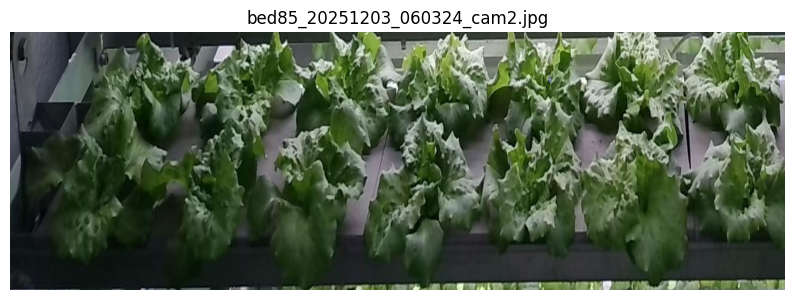

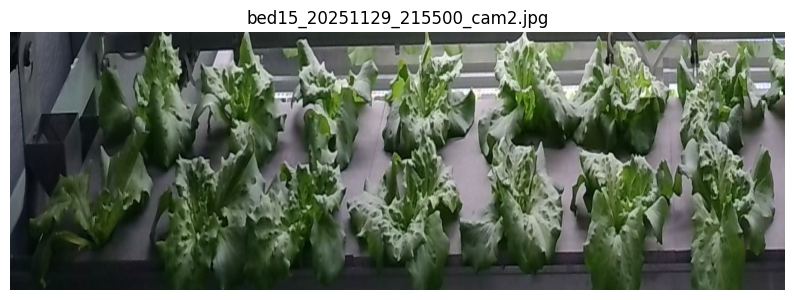

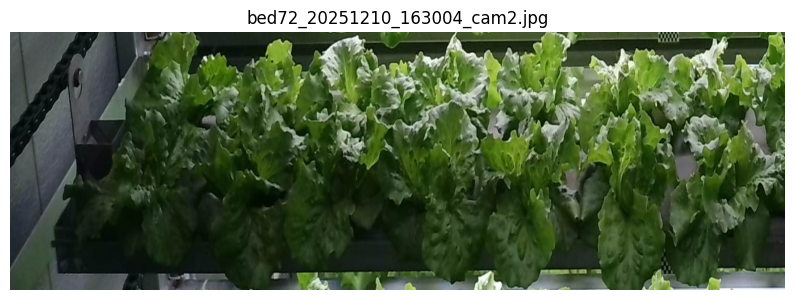

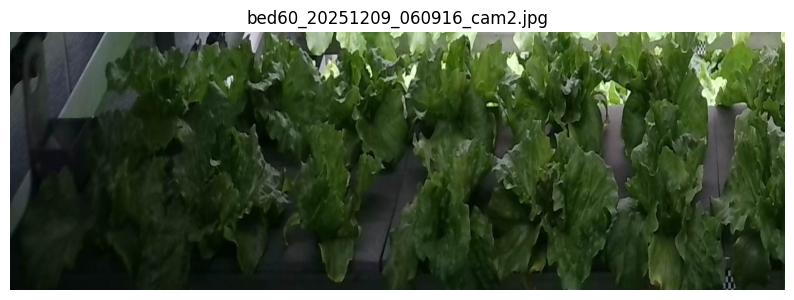

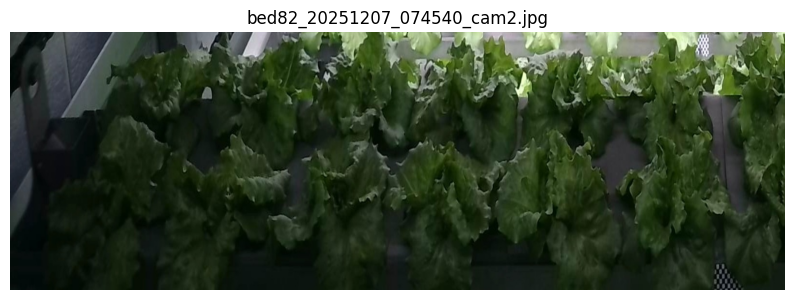

In [31]:
show_samples(result6["sample_paths"])
